# Pack temperature over a route: radiator or chiller?

A liquid-cooled pack can reject heat to the ambient through a radiator, or through a chiller on the refrigerant circuit.
The radiator is cheap to run but cannot cool below ambient. The chiller can, at an electrical cost.
This notebook simulates a two-hour hot-day route and compares four strategies on temperature and energy.

The pack, the route and the loop values are illustrative.

## 1. Model

One lumped pack temperature $T$ with thermal mass $C_{th}$:

$$C_{th}\frac{dT}{dt} = Q_{gen} - Q_{cool} - UA_{amb}(T-T_{amb})$$

Cooling through the plates, as a heat exchanger with effectiveness $\varepsilon$:

$$Q_{cool} = \varepsilon\,\dot m c_p\,(T-T_{in}), \qquad \varepsilon = 1-e^{-UA/(\dot m c_p)}$$

Chiller electrical power: $P_{el} = Q_{cool}/COP$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# pack (same illustrative cell values as the first notebook)
cap_Ah, R25, E_over_R, dUdT = 50.0, 1.0e-3, 2000.0, -0.1e-3
Ns, Np, m_cell, cp_cell = 96, 3, 0.9, 1000.0
Cth = Ns*Np*m_cell*cp_cell
def R0(T_C):
    T = T_C + 273.15
    return R25*np.exp(E_over_R*(1/T - 1/298.15))
def Q_gen(c_rate, T_C):
    I = c_rate*cap_Ah
    return Ns*Np*(I**2*R0(T_C) - I*(T_C+273.15)*dUdT)

# loop and environment
T_amb, UA_amb = 38.0, 20.0
mdot, cp = 0.30, 3300.0
UA_plate = 700.0
eps = 1 - np.exp(-UA_plate/(mdot*cp))
COP, P_pump = 2.5, 150.0
print(f'Heat exchanger effectiveness {eps:.2f}, Cth {Cth/1000:.0f} kJ/K')

Heat exchanger effectiveness 0.51, Cth 259 kJ/K


## 2. The route

A synthetic two-hour drive as pack C-rate (positive = discharge, negative = regeneration).

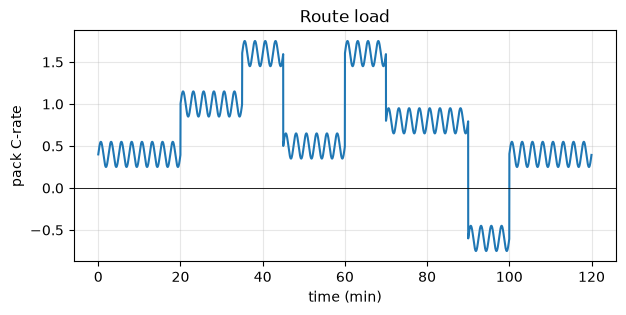

Mean discharge C-rate 0.79, peak 1.75


In [2]:
segments = [(20,0.4),(15,1.0),(10,1.6),(15,0.5),(10,1.6),(20,0.8),(10,-0.6),(20,0.4)]   # (minutes, C-rate)
t_end = sum(m for m, _ in segments)*60
t = np.arange(0, t_end, 1.0)
c_rate = np.zeros_like(t); k = 0
for m, c in segments:
    n = m*60; c_rate[k:k+n] = c + 0.15*np.sin(2*np.pi*np.arange(n)/150); k += n

plt.figure(figsize=(7, 3)); plt.plot(t/60, c_rate); plt.axhline(0, color='k', lw=.6)
plt.xlabel('time (min)'); plt.ylabel('pack C-rate'); plt.title('Route load'); plt.grid(alpha=.3); plt.show()
print(f'Mean discharge C-rate {c_rate[c_rate>0].mean():.2f}, peak {c_rate.max():.2f}')

## 3. Strategies

- **none:** no cooling.
- **radiator:** coolant inlet $T_{in}=T_{amb}+5$ °C, used whenever it is colder than the pack.
- **chiller late:** radiator until the pack reaches 40 °C, then chiller at $T_{in}=15$ °C until it falls to 37 °C.
- **chiller early:** same, switching on at 36 °C and off at 33 °C.

In [3]:
def simulate(strategy, T0=38.0):
    T = np.zeros_like(t); T[0] = T0
    chiller_on = False
    E_el = 0.0; on_time = 0
    on_at, off_at = {"chiller late": (40, 37), "chiller early": (36, 33)}.get(strategy, (None, None))
    for i in range(1, len(t)):
        Tp = T[i-1]
        Tin = None
        if strategy == 'radiator' or strategy.startswith('chiller'):
            Tin = T_amb + 5
        if on_at is not None:
            if not chiller_on and Tp > on_at: chiller_on = True
            if chiller_on and Tp < off_at:    chiller_on = False
            if chiller_on: Tin = 15.0
        Qc = 0.0
        if Tin is not None and Tp > Tin:
            Qc = eps*mdot*cp*(Tp - Tin)
        if chiller_on:
            E_el += (Qc/COP + P_pump)*1.0; on_time += 1
        elif Qc > 0:
            E_el += P_pump*1.0
        dT = (Q_gen(c_rate[i], Tp) - Qc - UA_amb*(Tp - T_amb))/Cth
        T[i] = Tp + dT
    return T, E_el/3.6e6, on_time/60

names = ['none', 'radiator', 'chiller late', 'chiller early']
res = {n: simulate(n) for n in names}

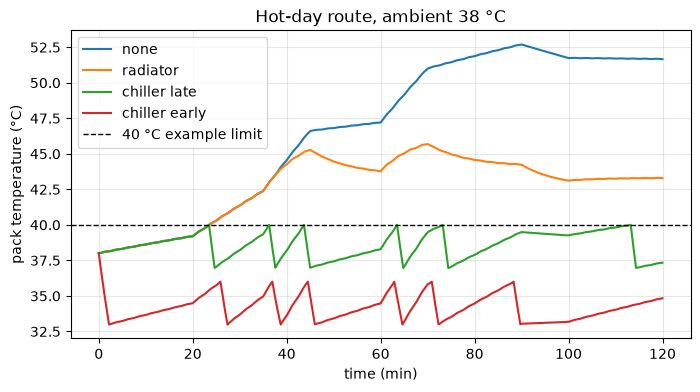

In [4]:
plt.figure(figsize=(8, 4))
for n in names:
    plt.plot(t/60, res[n][0], label=n)
plt.axhline(40, color='k', ls='--', lw=1, label='40 °C example limit')
plt.xlabel('time (min)'); plt.ylabel('pack temperature (°C)'); plt.title(f'Hot-day route, ambient {T_amb:.0f} °C')
plt.legend(); plt.grid(alpha=.3); plt.show()

In [5]:
print(f'{"strategy":<15}{"peak T (°C)":>12}{"min above 40 °C":>17}{"cooling energy (kWh)":>22}{"chiller on (min)":>18}')
for n in names:
    T, E, on = res[n]
    print(f'{n:<15}{T.max():>12.1f}{(T>40).sum()/60:>17.1f}{E:>22.2f}{on:>18.1f}')

strategy        peak T (°C)  min above 40 °C  cooling energy (kWh)  chiller on (min)
none                   52.7             96.5                  0.00               0.0
radiator               45.7             96.5                  0.21               0.0
chiller late           40.0              0.1                  0.61               7.5
chiller early          38.0              0.0                  0.79              11.5


**Observation.** With no cooling the pack passes 50 °C. The radiator slows the rise, but its coolant is never colder than 43 °C on a 38 °C day,
so it cannot hold a 40 °C limit and the pack peaks at about 46 °C. Only the chiller can bring the pack back inside the limit.
The earlier it switches on, the lower the peak, but the more electrical energy it uses. That energy comes from the battery and reduces range.

## 4. Energy cost against temperature

The trade-off in one picture: cooling energy against peak temperature.

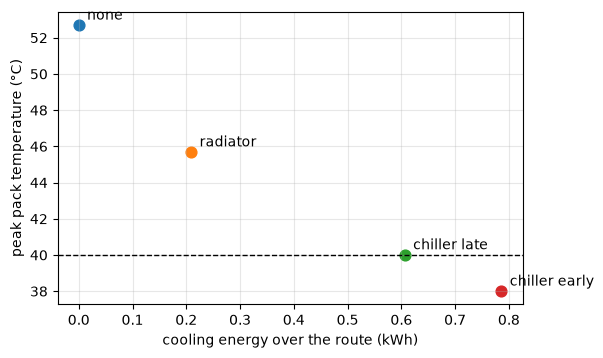

chiller late: 0.61 kWh is 1.1% of the 53 kWh pack
chiller early: 0.79 kWh is 1.5% of the 53 kWh pack


In [6]:
plt.figure(figsize=(6, 3.8))
for n in names:
    T, E, on = res[n]
    plt.scatter(E, T.max(), s=60); plt.annotate(n, (E, T.max()), textcoords='offset points', xytext=(6, 4))
plt.axhline(40, color='k', ls='--', lw=1)
plt.xlabel('cooling energy over the route (kWh)'); plt.ylabel('peak pack temperature (°C)'); plt.grid(alpha=.3); plt.show()
pack_kWh = Ns*3.7*cap_Ah*Np/1000
for n in ('chiller late', 'chiller early'):
    print(f'{n}: {res[n][1]:.2f} kWh is {res[n][1]/pack_kWh:.1%} of the {pack_kWh:.0f} kWh pack')

**Observation.** The best strategy is not the coldest one. A controller that only cools when the pack needs it holds the limit for less energy than one that
chills early. Comparing strategies fairly also means comparing them at the same end state: a pack that finishes warmer has borrowed thermal storage.

**Limits.** One lumped temperature, constant loop values, a synthetic route, fixed COP, no cabin load sharing the chiller.
The next step would be a shared battery and cabin refrigerant circuit and a real duty cycle.